# Quantum Protocols — Implementation

Companion notebook for **notes-protocols.md** and **notes-qcb.md**.  
Implements Bell states, superdense coding, teleportation, and a no-cloning test.

**Ket convention (little-endian).** Qiskit orders $\vert q_{n-1} \cdots q_1 q_0\rangle$ — qubit 0 is rightmost. $C^X_{01}\vert x,y\rangle = \vert x \oplus y, y\rangle$ with $y=q_0$ (control) and $x=q_1$ (target).

**Sources:** PS3 (Simple Circuits, 2026); Nielsen & Chuang Ch. 1.3.7, 2.3; Mermin Ch. 6.

---
## 0. Setup

The Qiskit stack has three layers:

1. **qiskit** (core): defines quantum circuits, registers, gates — the "blueprint" of a quantum program.
2. **qiskit-aer**: a classical simulator that runs those blueprints on your laptop, pretending to be a quantum computer.
3. **qiskit-ibm-runtime**: sends blueprints to real IBM quantum hardware in the cloud.

Below, `from qiskit import *` loads the core circuit-building tools. We then separately import the simulator (`AerSimulator`, `AerSampler`) and visualization (`plot_histogram`).

In [1]:
# Load all core Qiskit objects:
#   QuantumCircuit  — the object that holds your quantum program
#   QuantumRegister — a collection of qubits (quantum bits)
#   ClassicalRegister — a collection of classical bits (to store measurement results)
from qiskit import *

# NumPy: standard math library (we need np.pi for rotation angles)
import numpy as np

In [2]:
# Print the installed Qiskit version (for reproducibility)
import qiskit
print(qiskit.__version__)

2.3.0


In [3]:
# AerSampler: a "sampler" that runs a circuit many times (shots) on a simulated quantum computer
from qiskit_aer.primitives import SamplerV2 as AerSampler

# generate_preset_pass_manager: a "compiler" that translates your abstract circuit
#   into the specific gates that a backend (simulator or real device) actually supports.
#   Example: your circuit uses a Toffoli gate, but the device only has CNOT + single-qubit gates
#   → the pass manager decomposes Toffoli into those simpler gates.
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# AerSimulator: the simulated quantum computer itself.
#   AerSampler uses this internally, but we also need it as a "target"
#   so the pass manager knows which gates are allowed.
from qiskit_aer import AerSimulator

In [4]:
# plot_histogram: takes a dictionary like {'00': 2048, '11': 2048}
#   and draws a bar chart showing how often each outcome was measured.
from qiskit.visualization import plot_histogram

### IBM device setup (optional)

Run this cell only if you have a saved IBM Quantum account.
If you don't, just skip — all simulator cells will still work.

In [5]:
# QiskitRuntimeService: the "client" that talks to IBM's cloud quantum computers
from qiskit_ibm_runtime import QiskitRuntimeService

# Connect to IBM Quantum using your saved credentials
# (you must have run QiskitRuntimeService.save_account(...) once before)
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform", 
    token="    overwrite=True
)

service = QiskitRuntimeService(instance="open-instance")

# Pick the real quantum device that currently has the shortest queue
# simulator=False: only real hardware (not cloud simulators)
# operational=True: only devices that are currently online
backend_hw = service.least_busy(simulator=False, operational=True)
print(f"Running on: {backend_hw.name}")

# SamplerV2 (from ibm_runtime): same interface as AerSampler,
# but sends circuits to real hardware instead of simulating
from qiskit_ibm_runtime import SamplerV2 as Sampler
sampler_hw = Sampler(mode=backend_hw)

Running on: ibm_torino


---
## 1. Bell State — Create and Measure $\vert\Phi^+\rangle$

> **Notes:** notes-qcb.md §6, notes-protocols.md §1

**Goal.** Prepare $\vert\Phi^+\rangle = (\vert 00\rangle + \vert 11\rangle)/\sqrt{2}$ and verify by measurement.

$$\vert 00\rangle \xrightarrow{I \otimes H} \frac{\vert 00\rangle + \vert 01\rangle}{\sqrt{2}} \xrightarrow{C^X_{01}} \frac{\vert 00\rangle + \vert 11\rangle}{\sqrt{2}} = \vert\Phi^+\rangle$$

### Creating the circuit

In [6]:
# Allocate 2 qubits: q[0] and q[1]
q = QuantumRegister(2)

# Allocate 2 classical bits to store measurement outcomes
c = ClassicalRegister(2)

# Create a quantum circuit that uses these qubits and classical bits
bell = QuantumCircuit(q, c)

# Hadamard gate on qubit 0: transforms |0> into (|0>+|1>)/sqrt(2)
bell.h(q[0])

# CNOT gate: control=q[0], target=q[1]
# If q[0]=1, flip q[1]. Combined with H above, this creates the Bell state |Phi+>
bell.cx(q[0], q[1])

# Barrier: a visual divider in the circuit diagram (no physical effect)
# Also tells the compiler not to reorder gates across this line
bell.barrier()

# Measure both qubits: q[0] result goes into c[0], q[1] into c[1]
bell.measure(q, c)

### Visualizing the circuit

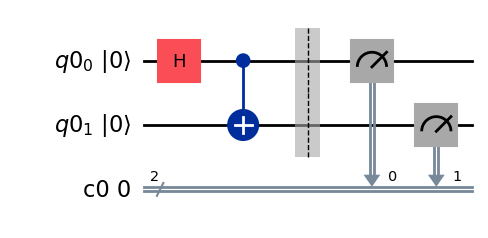

In [7]:
# Draw the circuit as a matplotlib figure
# output="mpl": use matplotlib (produces a nice image)
# initial_state=True: show |0> labels on each qubit wire
bell.draw(output="mpl", initial_state=True)

### Executing the circuit on the local Aer simulator

In [8]:
# Create a fresh simulator backend and sampler
# (we do this each section so each section is self-contained)
backend = AerSimulator()
sampler = AerSampler()

In [9]:
# "Compile" the circuit for this backend:
# The pass manager translates abstract gates into the simulator's native gate set
# optimization_level=1: light optimization (cancel redundant gates, basic routing)
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

# pm.run() returns the "ISA circuit" — the compiled version ready to execute
bell_isa = pm.run(bell)

In [10]:
# Run the compiled circuit 4096 times (shots)
# Each shot: prepare |00>, apply gates, measure → one bitstring like "00" or "11"
# After 4096 shots we get statistics: how often each outcome appeared
job_sim = sampler.run([bell_isa], shots=4096)

# .result() returns a list (one entry per circuit); [0] gets our first circuit's result
result_sim = job_sim.result()[0]

In [11]:
# Check what classical registers are in the result
# This tells us the key name to use when extracting counts
list(result_sim.data.keys())

['c0']

In [13]:
# Extract the measurement counts as a dictionary
# e.g. {'00': 2048, '11': 2048}
counts_sim = result_sim.data.c0.get_counts()
print(counts_sim)

{'11': 2058, '00': 2038}


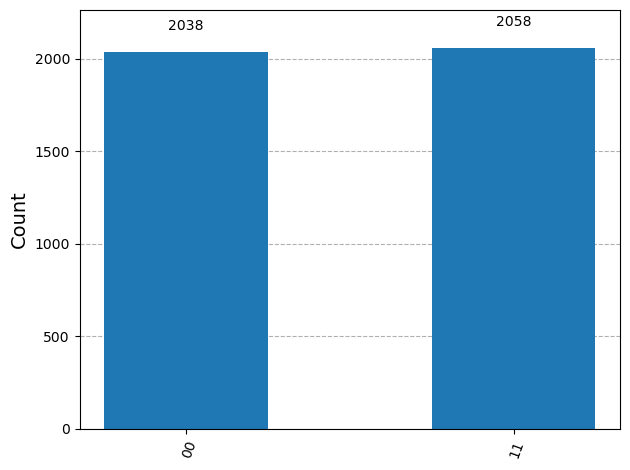

In [14]:
# Visualize as a bar chart
plot_histogram(counts_sim)

**Verification.** Only $\vert 00\rangle$ and $\vert 11\rangle$ appear, each $\approx 50\%$ — confirms $\vert\Phi^+\rangle$.

### Executing the circuit on a real device

In [15]:
# Compile the circuit for real hardware (different native gates and qubit layout)
pm_hw = generate_preset_pass_manager(optimization_level=1, backend=backend_hw)
isa_bell = pm_hw.run(bell)

In [16]:
# Submit the job to IBM's cloud — it enters a queue and waits for the device
# This can take 30 seconds to several minutes depending on queue length
job_exp = sampler_hw.run([isa_bell])
job_exp.job_id()

'd6ir0pkmmeis739qmltg'

In [17]:
# Check whether the job is still in the queue or has finished
job_exp.status()

'RUNNING'

In [19]:
# Retrieve the result (blocks until the job finishes)
result_exp = job_exp.result()[0]

# Extract counts from the hardware run
counts_exp = result_exp.data.c0.get_counts()
print(counts_exp)

{'11': 1675, '00': 1903, '10': 313, '01': 205}


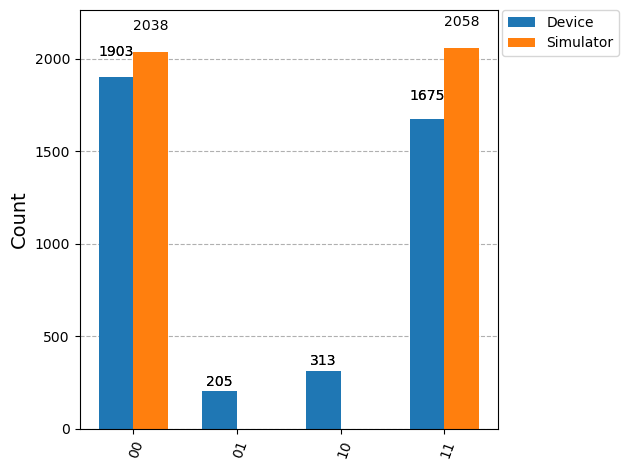

In [20]:
# Compare device and simulator side-by-side
plot_histogram([counts_exp, counts_sim], legend=["Device", "Simulator"])

**Device vs simulator.** On real hardware, $\vert 01\rangle$ and $\vert 10\rangle$ appear with small nonzero counts due to gate errors and decoherence.

---
## 2. Superdense Coding — 2 Bits via 1 Qubit + Shared Entanglement

> **Notes:** notes-protocols.md §4

**Goal.** Alice transmits 2 classical bits to Bob by sending 1 qubit, using 1 pre-shared Bell pair.

| Message | Alice's op | Effect | Bob measures |
|:---:|:---:|:---:|:---:|
| 00 | $I$ | $\vert\Phi^+\rangle$ | $\vert 00\rangle$ |
| 01 | $Z$ | $\vert\Phi^-\rangle$ | $\vert 01\rangle$ |
| 10 | $X$ | $\vert\Psi^+\rangle$ | $\vert 10\rangle$ |
| 11 | $ZX$ | $\vert\Psi^-\rangle$ | $\vert 11\rangle$ |

### The case 11

In [21]:
q = QuantumRegister(2)
c = ClassicalRegister(2)
dense11 = QuantumCircuit(q, c)

# Step 1: Create shared Bell pair |Phi+> between Alice (q[0]) and Bob (q[1])
dense11.h(q[0])           # H on Alice's qubit
dense11.cx(q[0], q[1])    # CNOT: creates entanglement
dense11.barrier()

# Step 2: Alice encodes message "11" by applying X (bit flip) then Z (phase flip)
dense11.x(q[0])
dense11.z(q[0])
dense11.barrier()

# Step 3: Alice sends her qubit to Bob (physically, not a gate)
# Step 4: Bob decodes — Bell measurement = CNOT then H
dense11.cx(q[0], q[1])    # CNOT: undo entanglement
dense11.h(q[0])           # H: rotate back to computational basis
dense11.barrier()

# Step 5: Bob measures both qubits to read Alice's 2-bit message
dense11.measure(q, c)

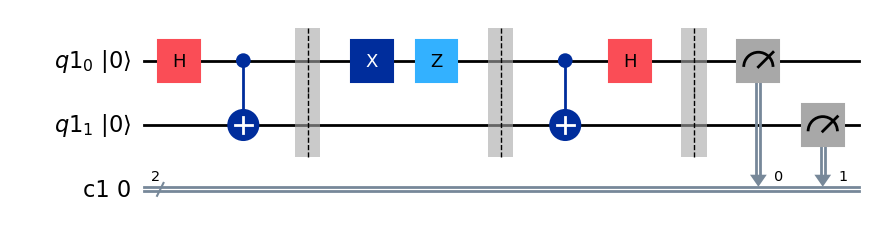

In [22]:
dense11.draw(output="mpl", initial_state=True)

In [23]:
backend = AerSimulator()
sampler = AerSampler()

In [24]:
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
dense11_isa = pm.run(dense11)

In [57]:
job_sim = sampler.run([dense11_isa], shots=4096)
result_sim = job_sim.result()[0]

In [58]:
counts_sim = result_sim.data.c1.get_counts()
print(counts_sim)

{'11': 4096}


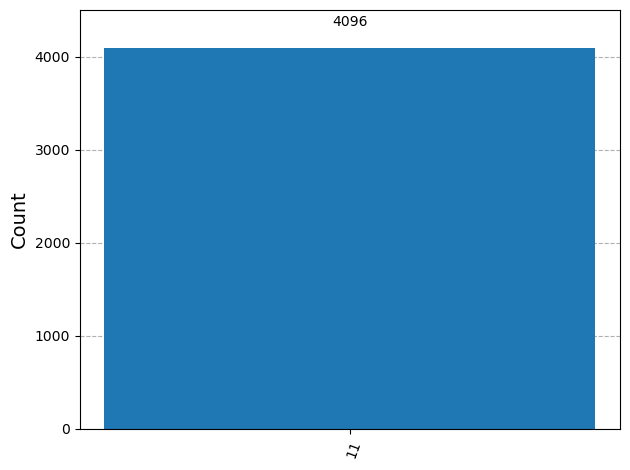

In [29]:
plot_histogram(counts_sim)

### The case 00

In [30]:
q = QuantumRegister(2)
c = ClassicalRegister(2)
dense00 = QuantumCircuit(q, c)

# Bell pair
dense00.h(q[0])
dense00.cx(q[0], q[1])
dense00.barrier()

# Alice encodes "00": apply nothing (identity)
dense00.barrier()

# Bob decodes
dense00.cx(q[0], q[1])
dense00.h(q[0])
dense00.barrier()
dense00.measure(q, c)

In [31]:
backend = AerSimulator()
sampler = AerSampler()

In [32]:
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
dense00_isa = pm.run(dense00)

In [33]:
job_sim = sampler.run([dense00_isa], shots=4096)
result_sim = job_sim.result()[0]

In [35]:
counts_sim = result_sim.data.c2.get_counts()
print(counts_sim)

{'00': 4096}


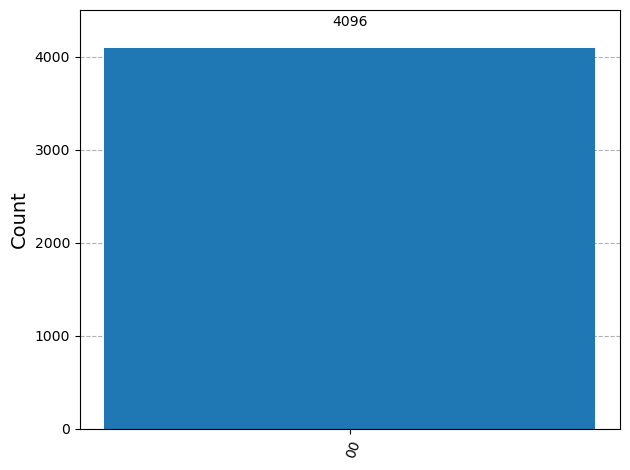

In [36]:
plot_histogram(counts_sim)

### The case 10

In [37]:
q = QuantumRegister(2)
c = ClassicalRegister(2)
dense10 = QuantumCircuit(q, c)
dense10.h(q[0])
dense10.cx(q[0], q[1])
dense10.barrier()

# Alice encodes "10": apply X (bit flip)
dense10.x(q[0])
dense10.barrier()

dense10.cx(q[0], q[1])
dense10.h(q[0])
dense10.barrier()
dense10.measure(q, c)

In [38]:
backend = AerSimulator()
sampler = AerSampler()

In [39]:
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
dense10_isa = pm.run(dense10)

In [40]:
job_sim = sampler.run([dense10_isa], shots=4096)
result_sim = job_sim.result()[0]

In [42]:
counts_sim = result_sim.data.c3.get_counts()
print(counts_sim)

{'10': 4096}


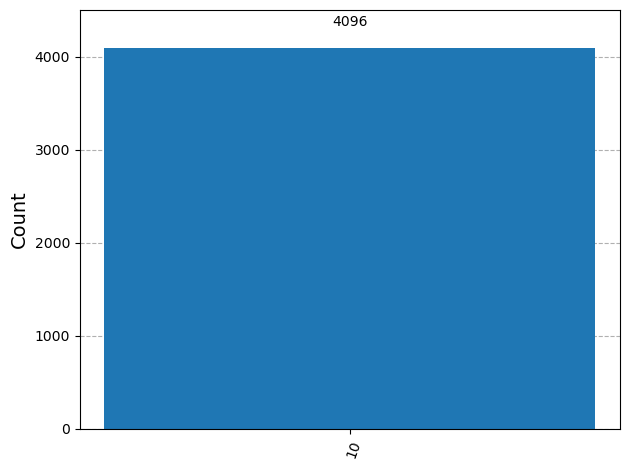

In [43]:
plot_histogram(counts_sim)

### The case 01

In [44]:
q = QuantumRegister(2)
c = ClassicalRegister(2)
dense01 = QuantumCircuit(q, c)
dense01.h(q[0])
dense01.cx(q[0], q[1])
dense01.barrier()

# Alice encodes "01": apply Z (phase flip)
dense01.z(q[0])
dense01.barrier()

dense01.cx(q[0], q[1])
dense01.h(q[0])
dense01.barrier()
dense01.measure(q, c)

In [45]:
backend = AerSimulator()
sampler = AerSampler()

In [46]:
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
dense01_isa = pm.run(dense01)

In [47]:
job_sim = sampler.run([dense01_isa], shots=4096)
result_sim = job_sim.result()[0]

In [48]:
counts_sim = result_sim.data.c4.get_counts()
print(counts_sim)

{'01': 4096}


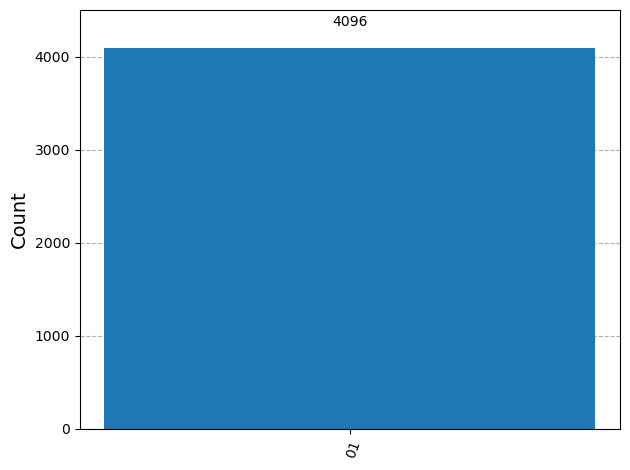

In [49]:
plot_histogram(counts_sim)

**Verification.** All four cases yield the intended message with probability 1. 1 qubit + 1 shared Bell pair → 2 classical bits transmitted.

### Executing the 11 circuit on a real device

In [50]:
pm_hw = generate_preset_pass_manager(optimization_level=1, backend=backend_hw)
isa_dense11 = pm_hw.run(dense11)

In [51]:
job_exp = sampler_hw.run([isa_dense11])
job_exp.job_id()

'd6ir1ikgmsgc73bu99qg'

In [52]:
job_exp.status()

'QUEUED'

In [54]:
result_exp = job_exp.result()[0]
counts_exp = result_exp.data.c1.get_counts()
print(counts_exp)

{'11': 3175, '00': 71, '01': 305, '10': 545}


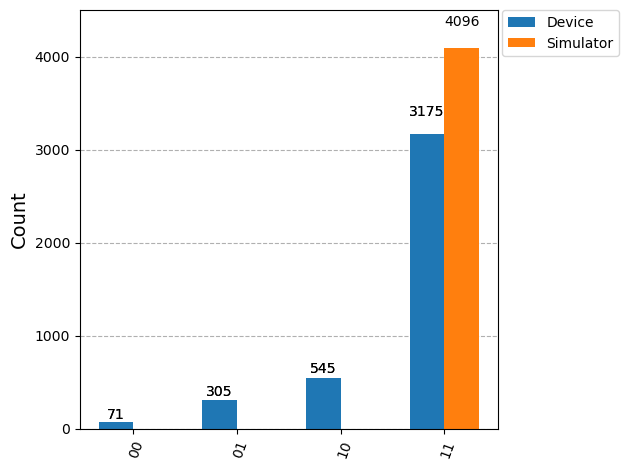

In [59]:
plot_histogram([counts_exp, counts_sim], legend=["Device", "Simulator"])

---
## 3. Teleportation — Transfer an Unknown Qubit State

> **Notes:** notes-protocols.md §3

**Goal.** Teleport $\vert\psi\rangle = R_Y(\pi/4)\vert 0\rangle = \cos(\pi/8)\vert 0\rangle - \sin(\pi/8)\vert 1\rangle$ from Alice to Bob.

1. Alice and Bob share $\vert\Phi^+\rangle_{12}$.
2. Alice: $C^X$ (control=$q_0$, target=$q_1$), then $H$ on $q_0$, then measure.
3. Bob: $X^{c_1} Z^{c_0}$ correction (classical feed-forward via `if_test`).

### Creating the circuit

In [60]:
# 3 qubits: q[0] = Alice's unknown state, q[1] = Alice's Bell half, q[2] = Bob's Bell half
q = QuantumRegister(3)

# Separate classical registers for each measurement
# (needed so we can condition Bob's gates on Alice's outcomes via if_test)
c0 = ClassicalRegister(1)   # stores measurement of q[0]
c1 = ClassicalRegister(1)   # stores measurement of q[1]
c2 = ClassicalRegister(1)   # stores measurement of q[2] (Bob's final result)
teleport = QuantumCircuit(q, c0, c1, c2)

In [61]:
# Prepare the "unknown" state |psi> = R_Y(pi/4)|0>
# ry(angle, qubit): rotation around the Y-axis of the Bloch sphere by the given angle
# This produces cos(pi/8)|0> - sin(pi/8)|1>
teleport.ry(np.pi/4, q[0])
teleport.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q5"), index=0>, <Qubit register=(3, "q5"), index=1>, <Qubit register=(3, "q5"), index=2>), clbits=())

In [62]:
# Create entangled Bell pair |Phi+> between q[1] (Alice) and q[2] (Bob)
teleport.h(q[1])
teleport.cx(q[1], q[2])
teleport.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q5"), index=0>, <Qubit register=(3, "q5"), index=1>, <Qubit register=(3, "q5"), index=2>), clbits=())

In [63]:
# === Teleportation protocol ===

# Alice applies CNOT: control=q[0] (unknown state), target=q[1] (her Bell qubit)
teleport.cx(q[0], q[1])

# Alice applies Hadamard to q[0]
teleport.h(q[0])
teleport.barrier()

# Alice measures her two qubits
teleport.measure(q[0], c0)   # result m0
teleport.measure(q[1], c1)   # result m1

# Classical feed-forward: Bob applies corrections based on Alice's results
# if_test: a conditional gate — "if this classical bit equals 1, apply the gate"
# This is the "classical communication" step of teleportation
with teleport.if_test((c1, 1)):   # if m1 = 1:
    teleport.x(q[2])             #   apply X (bit flip) to Bob's qubit
with teleport.if_test((c0, 1)):   # if m0 = 1:
    teleport.z(q[2])             #   apply Z (phase flip) to Bob's qubit

# Bob measures his qubit to verify the teleported state arrived correctly
teleport.measure(q[2], c2)

### Visualizing the circuit

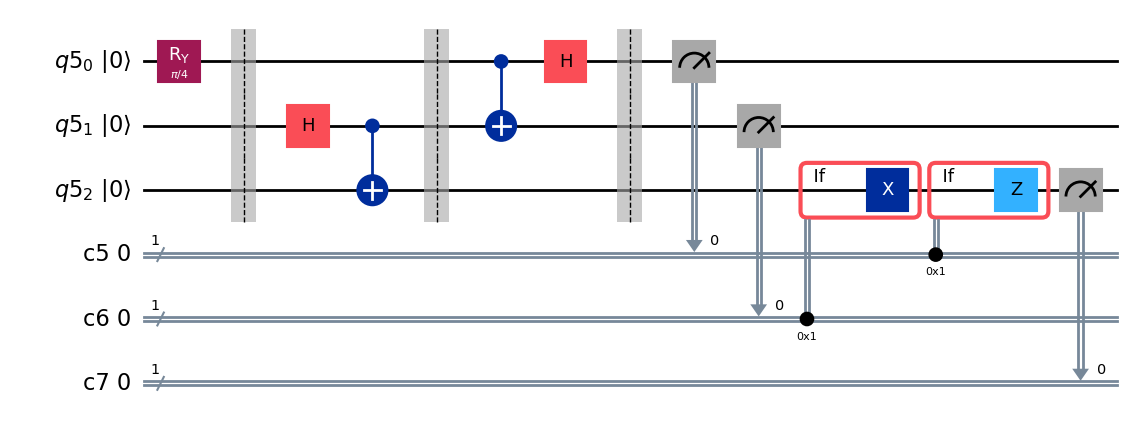

In [64]:
teleport.draw(output="mpl", initial_state=True)

### Executing the circuit on the local Aer simulator

In [65]:
backend = AerSimulator()
sampler = AerSampler()

In [66]:
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
teleport_isa = pm.run(teleport)

In [67]:
job_sim = sampler.run([teleport_isa], shots=4096)
result_sim = job_sim.result()[0]

# Show available register keys
list(result_sim.data.keys())

['c5', 'c6', 'c7']

In [68]:
# join_data(): merges all 3 separate classical registers (c0, c1, c2)
# into one combined bitstring per shot
# The result is a dictionary like {'000': 1500, '001': 200, ...}
data = result_sim.join_data().get_counts()
print(data)

{'011': 904, '001': 877, '000': 893, '101': 161, '100': 144, '010': 810, '111': 150, '110': 157}


Qiskit uses Little Endian ordering. In the combined bitstring, the rightmost bit is the first register (c0), and the leftmost bit is the last register (c2). So `'101'` means c2=1, c1=0, c0=1.

In [69]:
# Extract Bob's measurement outcome (c2 = leftmost bit in the bitstring)
# We sum over all possible values of Alice's measurements (c0, c1)
# k[0] picks the first character of the bitstring = c2 = Bob's result
bob = {}
bob['0'] = sum(v for k, v in data.items() if k[0] == '0')   # c2=0
bob['1'] = sum(v for k, v in data.items() if k[0] == '1')   # c2=1

In [70]:
print(bob)

# Compare with theory: P(0) = cos^2(pi/8), P(1) = sin^2(pi/8)
total = bob['0'] + bob['1']
print(f"P(0) = {bob['0']/total:.4f}  (theory: {np.cos(np.pi/8)**2:.4f})")
print(f"P(1) = {bob['1']/total:.4f}  (theory: {np.sin(np.pi/8)**2:.4f})")

{'0': 3484, '1': 612}
P(0) = 0.8506  (theory: 0.8536)
P(1) = 0.1494  (theory: 0.1464)


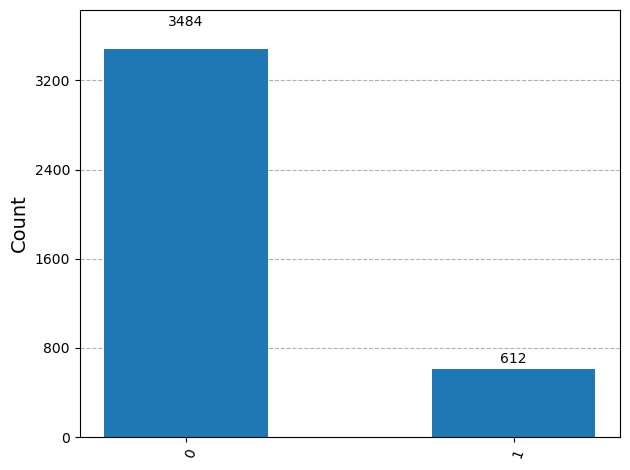

In [71]:
plot_histogram(bob)

**Verification.** $P(0) \approx 0.854$, $P(1) \approx 0.146$, matching $\cos^2(\pi/8)$ and $\sin^2(\pi/8)$ within statistical fluctuation ($\sim 1/\sqrt{4096}$).

### Multi-basis verification (simple state tomography)

Z-basis alone cannot fully verify teleportation — e.g., $\cos\theta\vert 0\rangle + \sin\theta\vert 1\rangle$ and $\cos\theta\vert 0\rangle - \sin\theta\vert 1\rangle$ give the same $P(0), P(1)$. We also measure Bob in X and Y bases, reconstructing the Bloch vector $\vec{r} = (\langle X\rangle, \langle Y\rangle, \langle Z\rangle)$.

For $\vert\psi\rangle = R_Y(\pi/4)\vert 0\rangle$: $\langle X\rangle = 1/\sqrt{2}$, $\langle Y\rangle = 0$, $\langle Z\rangle = +1/\sqrt{2}$.

In [72]:
def build_teleport(basis='Z'):
    """Build the same teleportation circuit, but with a configurable measurement basis.
    
    basis='Z': measure directly (computational basis)
    basis='X': apply H before measuring (measures in the X-basis)
    basis='Y': apply S-dagger then H before measuring (measures in the Y-basis)
    
    This lets us measure <X>, <Y>, <Z> expectation values to reconstruct
    the full Bloch vector of the teleported state.
    """
    q = QuantumRegister(3)
    c0, c1, c2 = ClassicalRegister(1), ClassicalRegister(1), ClassicalRegister(1)
    qc = QuantumCircuit(q, c0, c1, c2)

    qc.ry(np.pi/4, q[0])             # prepare |psi>
    qc.barrier()
    qc.h(q[1])                        # Bell pair
    qc.cx(q[1], q[2])
    qc.barrier()
    qc.cx(q[0], q[1])                 # Alice: CNOT + H + measure
    qc.h(q[0])
    qc.barrier()
    qc.measure(q[0], c0)
    qc.measure(q[1], c1)

    with qc.if_test((c1, 1)):         # Bob: corrections
        qc.x(q[2])
    with qc.if_test((c0, 1)):
        qc.z(q[2])

    # Rotate Bob's qubit into the desired measurement basis
    if basis == 'X':
        qc.h(q[2])          # H maps X-eigenstates to Z-eigenstates
    elif basis == 'Y':
        qc.sdg(q[2])        # S-dagger: rotates Y-axis to X-axis
        qc.h(q[2])          # then H maps X to Z
    # 'Z': no extra rotation needed

    qc.measure(q[2], c2)
    return qc

In [73]:
backend = AerSimulator()
sampler = AerSampler()

# Run the teleportation circuit three times: once for each measurement basis
bloch = {}
for basis in ['Z', 'X', 'Y']:
    qc = build_teleport(basis)

    # Compile and run (same pattern as before)
    pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
    qc_isa = pm.run(qc)
    job = sampler.run([qc_isa], shots=4096)
    result = job.result()[0]

    # Extract Bob's counts
    data = result.join_data().get_counts()
    p0 = sum(v for k, v in data.items() if k[0] == '0')
    p1 = sum(v for k, v in data.items() if k[0] == '1')

    # Expectation value: <sigma> = P(outcome +1) - P(outcome -1)
    # For a Pauli operator, eigenvalue +1 corresponds to |0>, eigenvalue -1 to |1>
    bloch[basis] = (p0 - p1) / (p0 + p1)
    print(f"<{basis}> = {bloch[basis]:+.4f}  (P(0)={p0/(p0+p1):.4f})")

<Z> = +0.6919  (P(0)=0.8459)
<X> = +0.6904  (P(0)=0.8452)
<Y> = +0.0054  (P(0)=0.5027)


In [88]:
# Compare measured Bloch vector with theory
theory = {
    'X': np.sin(np.pi/4),   # -1/sqrt(2)
    'Y': 0.0,
    'Z': np.cos(np.pi/4),    # +1/sqrt(2)
}

print(f"{'Basis':<6} {'Measured':>10} {'Theory':>10} {'|Error|':>10}")
print("─" * 40)
for b in ['X', 'Y', 'Z']:
    print(f"<{b}>    {bloch[b]:>+10.4f} {theory[b]:>+10.4f} {abs(bloch[b]-theory[b]):>10.4f}")

# Bloch vector norm: should be 1.0 for a pure state
norm = np.sqrt(sum(v**2 for v in bloch.values()))
print(f"\n|r| = {norm:.4f}  (pure state -> 1.0)")

Basis    Measured     Theory    |Error|
────────────────────────────────────────
<X>       +0.6904    +0.7071     0.0167
<Y>       +0.0054    +0.0000     0.0054
<Z>       +0.6919    +0.7071     0.0152

|r| = 0.9775  (pure state -> 1.0)


**Verification.** All three Bloch components match theory within $\sim 1/\sqrt{4096} \approx 0.016$. $\vert\vec{r}\vert \approx 1$ confirms the state remained pure.

### Executing the circuit on a real device

In [75]:
pm_hw = generate_preset_pass_manager(optimization_level=1, backend=backend_hw)
teleport_hw = pm_hw.run(teleport)

In [76]:
job_exp = sampler_hw.run([teleport_hw])
job_exp.job_id()

'd6ir2km33pjc73dl6a3g'

In [77]:
job_exp.status()

'QUEUED'

In [78]:
result_exp = job_exp.result()[0]
data_hw = result_exp.join_data().get_counts()

# Extract Bob's counts from hardware
bob_hw = {}
bob_hw['0'] = sum(v for k, v in data_hw.items() if k[0] == '0')
bob_hw['1'] = sum(v for k, v in data_hw.items() if k[0] == '1')
print(bob_hw)

{'0': 3173, '1': 923}


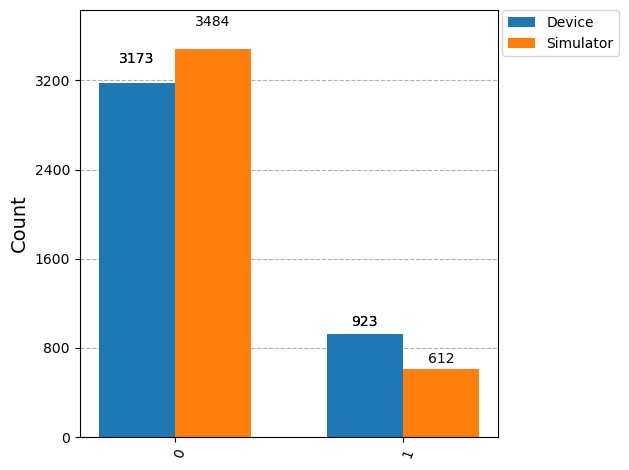

In [79]:
plot_histogram([bob_hw, bob], legend=["Device", "Simulator"])